#### Imports

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from pathlib import Path
import subprocess
import sys

#### EDA

In [59]:
# Training&validation data is: train-test.csv
#load data
df = pd.read_csv('data/train-test.csv')
df.head()


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [60]:
# Categorical features: pickup, delivery, equipment
cat_cols = ["pickup", "delivery", "equipment"]
for col in cat_cols:
    print("================================")
    print(f"{col}: unique={df[col].nunique()}, nulls={df[col].isna().sum()}")
    print(df[col].value_counts(dropna=False).to_string())
    print()


pickup: unique=64, nulls=0
pickup
Oklahoma City     1242
Lexington         1209
Bakersfield       1193
Fort Wayne        1170
Hartford          1150
Richmond          1140
Nashville         1124
Phoenix           1121
Baton Rouge       1115
Mobile            1094
Cincinnati        1080
Shreveport        1062
Kansas City       1053
Columbia          1049
Atlanta           1029
San Antonio        972
Philadelphia       946
Los Angeles        945
Milwaukee          944
Tucson             944
Syracuse           907
Montgomery         884
Greensboro         865
Memphis            852
Charleston         848
Grand Rapids       844
Amarillo           836
Fresno             827
New York           816
Albany             811
Lubbock            796
El Paso            768
Chattanooga        745
Toledo             745
Buffalo            738
Houston            723
Jacksonville       666
Green Bay          662
Reno               642
Tulsa              633
Raleigh            607
Boston             603


In [61]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


Initial review:
<li> 48K rows total
<li> 14 features, including 1 load_id
<li> Only 2 features have missing data: weight (0.625% null values) and market index (0.779% null values)
<li> 9 numerical variables (8 independent + 1 dependent target), 3 categorical variables, 1 date variable, 1 id.

In [62]:
# Compare categoricals: train-test vs held-out validation.csv
val = pd.read_csv("data/validation.csv")

for col in cat_cols:
    train_vals = set(df[col].dropna().astype(str))
    val_vals = set(val[col].dropna().astype(str))
    only_train = sorted(train_vals - val_vals)
    only_val = sorted(val_vals - train_vals)
    print("=" * 60)
    print(
        f"{col}: train={len(train_vals)}, val={len(val_vals)}, "
        f"overlap={len(train_vals & val_vals)}"
    )
    print(f"  only in train ({len(only_train)}): {only_train}")
    print(f"  only in val   ({len(only_val)}): {only_val}")
    print()



pickup: train=64, val=72, overlap=64
  only in train (0): []
  only in val   (8): ['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']



delivery: train=64, val=72, overlap=64
  only in train (0): []
  only in val   (8): ['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']

equipment: train=3, val=3, overlap=3
  only in train (0): []
  only in val   (0): []



In [63]:
# Numeric feature quick scan (nulls + negatives that look like data issues)
num_cols = df.select_dtypes(include="number").columns.tolist()
summary = pd.DataFrame({
    "nulls": df[num_cols].isna().sum(),
    "null_pct": (df[num_cols].isna().mean() * 100).round(3),
    "min": df[num_cols].min(),
    "max": df[num_cols].max(),
})
summary

,nulls,null_pct,min,max
pickup_lat,0,0.000,28.35765,44.30296
pickup_lon,0,0.000,-121.69849,-69.50000
delivery_lat,0,0.000,28.35765,44.30296
delivery_lon,0,0.000,-121.69849,-69.50000
distance,0,0.000,70.00000,3439.80000
weight,300,0.625,-47500.00000,47500.00000
market_index,374,0.779,0.67639,1.46778
quote_signal,0,0.000,0.69228,3.61035
posted_rate,0,0.000,57.22000,25533.00000


In [64]:
df_eda = df.copy()

In [65]:
df_eda["date"] = pd.to_datetime(df_eda["date"])
df_eda["rate_per_mile"] = df_eda["posted_rate"] / df_eda["distance"]

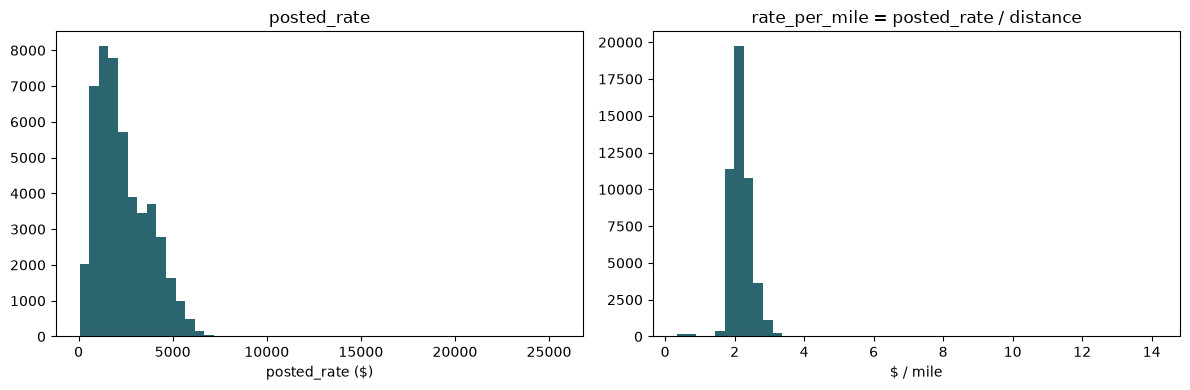

posted_rate describe:
 count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64

rate_per_mile describe:
 count    48000.000000
mean         2.215347
std          0.583887
min          0.333709
25%          1.986974
50%          2.145348
75%          2.342696
max         14.125294
Name: rate_per_mile, dtype: float64


In [66]:
#Explore target distribution: 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["posted_rate"], bins=50, color="#064A56", alpha=0.85)
axes[0].set_title("posted_rate")
axes[0].set_xlabel("posted_rate ($)")
axes[1].hist(df_eda["rate_per_mile"].replace([np.inf, -np.inf], np.nan).dropna(), bins=50, color="#064A56", alpha=0.85)
axes[1].set_title("rate_per_mile = posted_rate / distance")
axes[1].set_xlabel("$ / mile")
plt.tight_layout()
plt.show()

print("posted_rate describe:\n", df_eda["posted_rate"].describe())
print("\nrate_per_mile describe:\n", df_eda["rate_per_mile"].describe())


In [67]:
print("\nload_id unique?", df_eda["load_id"].is_unique)
print("load_id nunique:", df_eda["load_id"].nunique(), "rows:", len(df_eda))


load_id unique? True
load_id nunique: 48000 rows: 48000


corr(market_index, posted_rate) = 0.0342
corr(quote_signal, posted_rate) = -0.0399
corr(distance, posted_rate) = 0.9085
corr(weight, posted_rate) = 0.0348


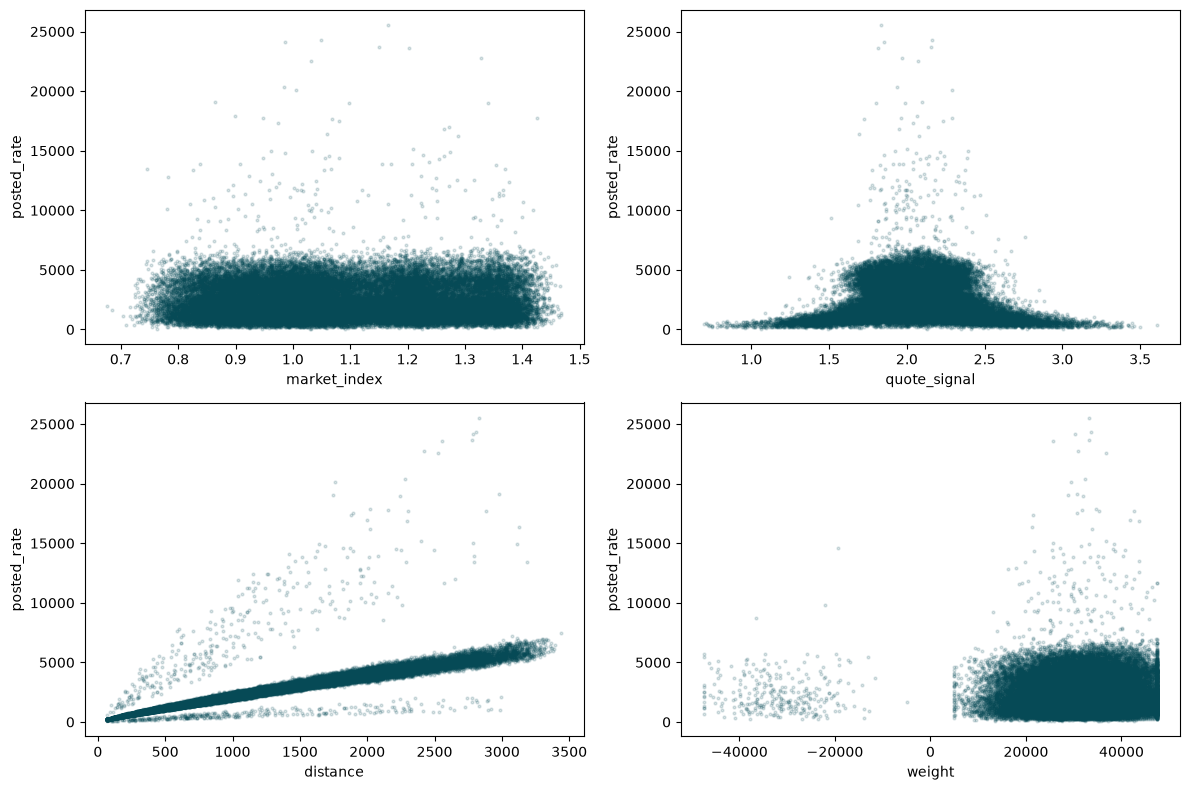

In [68]:
# Inspecting correlation between some market signals and the target
# Excluded long and lat because they are not expected to impact target directly
for col in ["market_index", "quote_signal", "distance", "weight"]:
    r = df_eda[[col, "posted_rate"]].corr().iloc[0, 1]
    print(f"corr({col}, posted_rate) = {r:.4f}")

# Scatter checks (2x2 grid uses axes[row, col])
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].scatter(df_eda["market_index"], df_eda["posted_rate"], s=4, alpha=0.15, color="#064A56")
axes[0, 0].set_xlabel("market_index")
axes[0, 0].set_ylabel("posted_rate")

axes[0, 1].scatter(df_eda["quote_signal"], df_eda["posted_rate"], s=4, alpha=0.15, color="#064A56")
axes[0, 1].set_xlabel("quote_signal")
axes[0, 1].set_ylabel("posted_rate")

axes[1, 0].scatter(df_eda["distance"], df_eda["posted_rate"], s=4, alpha=0.15, color="#064A56")
axes[1, 0].set_xlabel("distance")
axes[1, 0].set_ylabel("posted_rate")

axes[1, 1].scatter(df_eda["weight"], df_eda["posted_rate"], s=4, alpha=0.15, color="#064A56")
axes[1, 1].set_xlabel("weight")
axes[1, 1].set_ylabel("posted_rate")

plt.tight_layout()
plt.show()



Correlation with posted_rate (sorted):
distance         0.908519
delivery_lon    -0.257086
pickup_lon      -0.255058
delivery_lat    -0.091970
pickup_lat      -0.090873
quote_signal    -0.039858
weight           0.034840
market_index     0.034165
rate_per_mile    0.003147
Name: posted_rate, dtype: float64


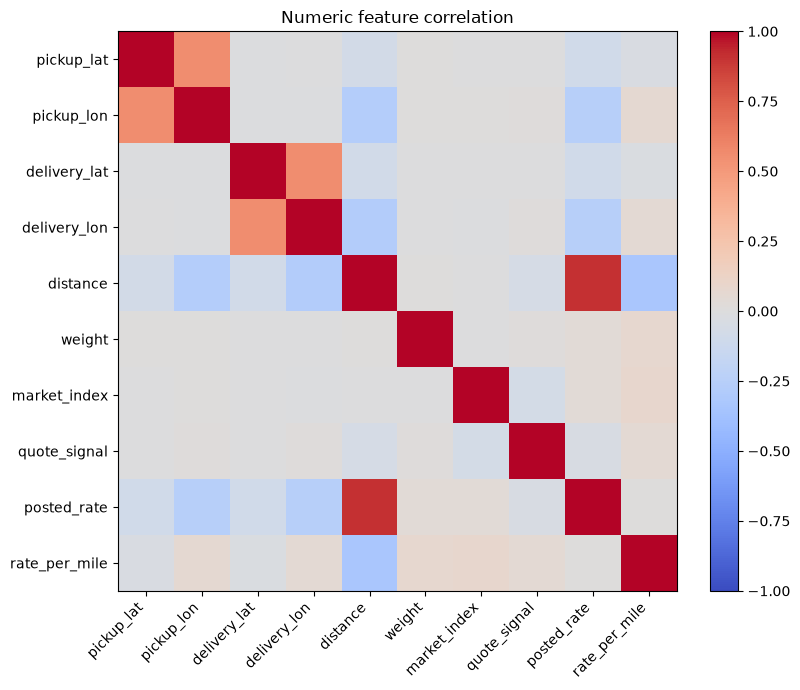

In [69]:
# Inspecting full correlation matrix of numerical features
num_cols = df_eda.select_dtypes(include="number").columns.tolist()
corr = df_eda[num_cols].corr()
print("\nCorrelation with posted_rate (sorted):")
print(corr["posted_rate"].drop("posted_rate").sort_values(key=np.abs, ascending=False))
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
ax.set_title("Numeric feature correlation")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

#### Inspecting dates to avoid leakage from the future

Blind `validation.csv` is later in time than development data. A random split of `train-test.csv` would train on future loads and overstate accuracy. Inspect the timeline, then use a **time-ordered** holdout for model selection.


train-test date range: 2025-01-01 -> 2025-10-31
validation date range: 2025-11-01 -> 2025-12-31
train-test months:
 date
2025-01    4918
2025-02    4337
2025-03    5036
2025-04    4819
2025-05    4913
2025-06    4783
2025-07    4912
2025-08    4759
2025-09    4670
2025-10    4853
Freq: M, Name: count, dtype: int64

validation months:
 date
2025-11    5836
2025-12    6164
Freq: M, Name: count, dtype: int64


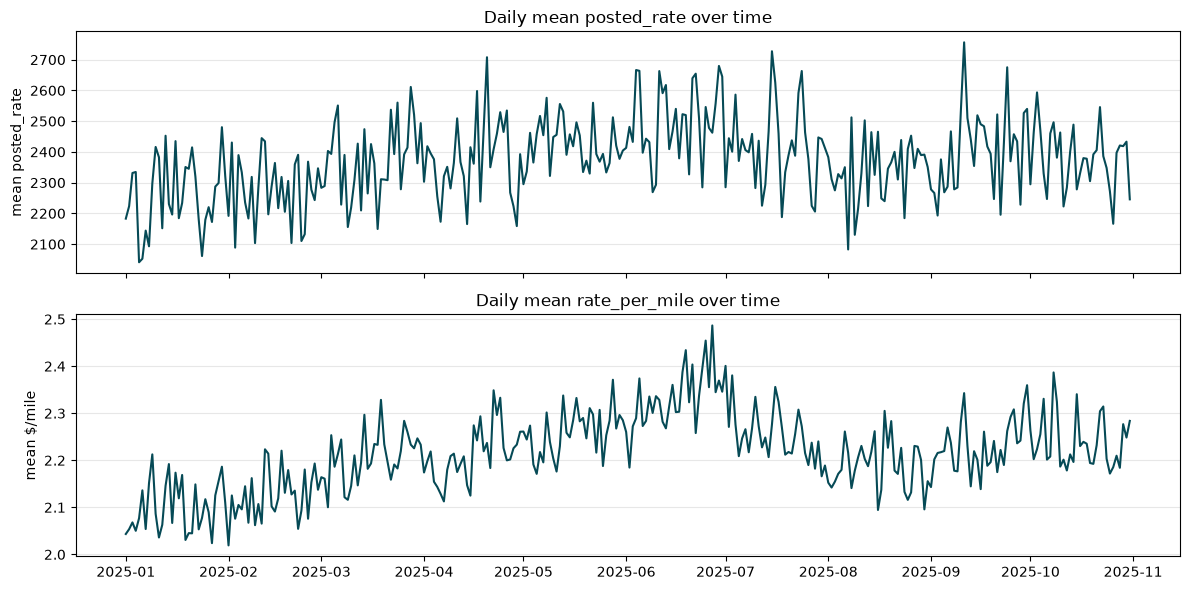

In [70]:
# Timeline: development data vs blind validation holdout
val_eda = val.copy()
val_eda["date"] = pd.to_datetime(val_eda["date"])

print("train-test date range:", df_eda["date"].min().date(), "->", df_eda["date"].max().date())
print("validation date range:", val_eda["date"].min().date(), "->", val_eda["date"].max().date())
print("train-test months:\n", df_eda["date"].dt.to_period("M").value_counts().sort_index())
print("\nvalidation months:\n", val_eda["date"].dt.to_period("M").value_counts().sort_index())

# Daily mean rate (and volume) over time
daily = (
    df_eda.groupby("date")
    .agg(n=("posted_rate", "size"), mean_rate=("posted_rate", "mean"), mean_rpm=("rate_per_mile", "mean"))
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(daily["date"], daily["mean_rate"], color="#064A56", linewidth=1.5)
axes[0].set_ylabel("mean posted_rate")
axes[0].set_title("Daily mean posted_rate over time")
axes[0].grid(axis="y", alpha=0.3)

axes[1].plot(daily["date"], daily["mean_rpm"], color="#064A56", linewidth=1.5)
axes[1].set_ylabel("mean $/mile")
axes[1].set_title("Daily mean rate_per_mile over time")
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


#### Data quality


In [71]:
# Data-quality checks on train-test
qc = pd.DataFrame({
    "nulls": df_eda.isna().sum(),
    "null_pct": (df_eda.isna().mean() * 100).round(3),
})
print("Missingness:\n", qc[qc["nulls"] > 0], "\n")

print("negative weight rows:", int((df_eda["weight"] < 0).sum()))
print("zero/neg distance rows:", int((df_eda["distance"] <= 0).sum()))
print("non-positive posted_rate rows:", int((df_eda["posted_rate"] <= 0).sum()))

# Weight by equipment (negatives / extremes stand out here)
print("\nweight describe by equipment:")
print(df_eda.groupby("equipment")["weight"].describe()[["count", "min", "25%", "50%", "75%", "max"]])

# Same city coords should be stable (pickup name -> lat/lon)
pickup_coords = df_eda.groupby("pickup")[["pickup_lat", "pickup_lon"]].nunique()
delivery_coords = df_eda.groupby("delivery")[["delivery_lat", "delivery_lon"]].nunique()
print("\npickups with >1 distinct lat/lon:", int((pickup_coords.max(axis=1) > 1).sum()))
print("deliveries with >1 distinct lat/lon:", int((delivery_coords.max(axis=1) > 1).sum()))

# Duplicate feature fingerprints (excluding load_id / target)
feat_cols = [c for c in df_eda.columns if c not in ["load_id", "posted_rate", "rate_per_mile"]]
dup_mask = df_eda.duplicated(subset=feat_cols, keep=False)
print("rows sharing identical features (excl. id/target):", int(dup_mask.sum()))


Missingness:
               nulls  null_pct
weight          300     0.625
market_index    374     0.779 

negative weight rows: 292
zero/neg distance rows: 0
non-positive posted_rate rows: 0

weight describe by equipment:
             count      min       25%      50%      75%      max
equipment                                                       
Dry Van    27027.0 -47500.0  25768.00  31373.0  36972.0  47500.0
Flatbed     8698.0 -47500.0  25830.25  31462.5  37053.0  47500.0
Reefer     11975.0 -47500.0  25845.00  31524.0  37078.0  47500.0

pickups with >1 distinct lat/lon: 0
deliveries with >1 distinct lat/lon: 0
rows sharing identical features (excl. id/target): 0


#### Train / validation split (time-ordered)

Use the last portion of `train-test.csv` by date as an internal holdout. Blind `validation.csv` stays untouched for final predictions only.


In [72]:
# Time-ordered split: train on earlier dates, hold out the most recent days
df_sorted = df_eda.sort_values("date").reset_index(drop=True)

# Hold out the last 20% of rows by time (equiv. to a late-date cut)
cut_idx = int(len(df_sorted) * 0.80)
split_date = df_sorted.loc[cut_idx, "date"]

train_df = df_sorted[df_sorted["date"] < split_date].copy()
valid_df = df_sorted[df_sorted["date"] >= split_date].copy()

print("split_date (inclusive for valid):", split_date.date())
print(f"train: {len(train_df):,} rows | {train_df['date'].min().date()} -> {train_df['date'].max().date()}")
print(f"valid: {len(valid_df):,} rows | {valid_df['date'].min().date()} -> {valid_df['date'].max().date()}")

# Sanity: no date overlap
assert train_df["date"].max() < valid_df["date"].min()

# Baseline RMSE if we predict train mean rate (reference only)
baseline_pred = train_df["posted_rate"].mean()
baseline_rmse = np.sqrt(np.mean((valid_df["posted_rate"] - baseline_pred) ** 2))
print(f"\nbaseline (predict train mean={baseline_pred:.2f}) valid RMSE: {baseline_rmse:.2f}")


split_date (inclusive for valid): 2025-08-31
train: 38,330 rows | 2025-01-01 -> 2025-08-30
valid: 9,670 rows | 2025-08-31 -> 2025-10-31

baseline (predict train mean=2369.48) valid RMSE: 1523.49


#### Feature engineering
clean and encode

Fit imputation stats on **train only**, then apply to train/valid (and later to blind `validation.csv`).  
- `weight`: treat negatives as missing; fill with **global train median** (equipment medians are nearly identical — see inspection below)  
- `market_index`: fill with **median by calendar month** (fallback: global train median)  
- `equipment`: **one-hot** (3 categories)  
- `date`: add **month**, **dayofweek**, **is_weekend** (city name encoding skipped for now; keep lat/lon as-is)



In [73]:
# Inspect weight median by equipment (train only; negatives treated as missing)
w_train = train_df["weight"].where(train_df["weight"] >= 0)
weight_by_eq = w_train.groupby(train_df["equipment"]).median().sort_index()
weight_global = w_train.median()

weight_median_cmp = weight_by_eq.to_frame("median_weight")
weight_median_cmp["vs_global"] = weight_median_cmp["median_weight"] - weight_global
weight_median_cmp["pct_diff_vs_global"] = (
    100 * weight_median_cmp["vs_global"] / weight_global
).round(2)

print(f"global train median weight: {weight_global:.2f}")
print(weight_median_cmp)
print(
    f"\nmax |pct diff| vs global: {weight_median_cmp['pct_diff_vs_global'].abs().max():.2f}%"
)
print(
    "Conclusion: equipment medians are very similar -> use global median for simplicity."
)


global train median weight: 31469.00
           median_weight  vs_global  pct_diff_vs_global
equipment                                              
Dry Van          31418.0      -51.0               -0.16
Flatbed          31511.0       42.0                0.13
Reefer           31541.5       72.5                0.23

max |pct diff| vs global: 0.23%
Conclusion: equipment medians are very similar -> use global median for simplicity.


In [91]:
def fit_impute_stats(train: pd.DataFrame) -> dict:
    """Learn fill values from train only."""
    w = train["weight"].where(train["weight"] >= 0)  # negatives -> treated as missing
    weight_global = w.median()

    mi = train["market_index"]
    month = train["date"].dt.to_period("M")
    mi_by_month = mi.groupby(month).median()
    mi_global = mi.median()

    return {
        "weight_global": weight_global,
        "market_index_by_month": mi_by_month,
        "market_index_global": mi_global,
        "equipment_categories": sorted(train["equipment"].dropna().unique().tolist()),
    }


def apply_impute(df: pd.DataFrame, stats: dict) -> pd.DataFrame:
    """Return a copy with weight / market_index cleaned + filled."""
    out = df.copy()

    # Weight: invalidate negatives, then global median
    out["weight"] = out["weight"].where(out["weight"] >= 0)
    out["weight"] = out["weight"].fillna(stats["weight_global"])

    # Market index: median-by-month (Period), fallback global
    month = out["date"].dt.to_period("M")
    month_median = month.map(stats["market_index_by_month"])
    out["market_index"] = out["market_index"].fillna(month_median).fillna(stats["market_index_global"])

    return out


def add_equipment_ohe(df: pd.DataFrame, categories: list[str]) -> pd.DataFrame:
    """One-hot encode equipment with a fixed category set from train."""
    out = df.copy()
    dummies = pd.get_dummies(out["equipment"], prefix="equipment")
    # Ensure all train categories exist; drop extras not seen in train
    for cat in categories:
        col = f"equipment_{cat}"
        if col not in dummies.columns:
            dummies[col] = 0
    dummies = dummies[[f"equipment_{c}" for c in categories]]
    out = pd.concat([out.drop(columns=["equipment"]), dummies], axis=1)
    return out

def add_date_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add month, day of week, and weekend flag from date."""
    out = df.copy()
    out["month"] = out["date"].dt.month
    out["dayofweek"] = out["date"].dt.dayofweek  # Mon=0 ... Sun=6
    out["is_weekend"] = (out["dayofweek"] >= 5).astype(int)
    return out

def add_weight_density(df: pd.DataFrame) -> pd.DataFrame:
    """Calculates weight per mile to capture fixed haul load density."""
    df = df.copy()
    df['weight_per_mile'] = df['weight'] / (df['distance'] + 1.0)
    return df

def add_payload_utilization(df: pd.DataFrame, max_payload: float = 45000.0) -> pd.DataFrame:
    """Calculates percentage of standard class-8 trailer capacity used."""
    df = df.copy()
    df['payload_utilization'] = df['weight'] / max_payload
    return df

def add_market_tightness(df: pd.DataFrame) -> pd.DataFrame:
    """Combines supply and demand indices into a joint market tightness signal."""
    df = df.copy()
    df['market_tightness'] = df['market_index'] * df['quote_signal']
    df['market_to_distance'] = df['market_tightness'] / (df['distance'] + 1.0)
    return df

def add_equipment_interactions(df: pd.DataFrame) -> pd.DataFrame:
    """Captures conditional distance and weight scaling per trailer type."""
    df = df.copy()
    if 'equipment_Reefer' in df.columns:
        df['reefer_distance'] = df['equipment_Reefer'] * df['distance']
    if 'equipment_Flatbed' in df.columns:
        df['flatbed_weight'] = df['equipment_Flatbed'] * df['weight']
    return df

def add_cyclical_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """Encodes month and dayofweek onto continuous 2D sine/cosine circles."""
    df = df.copy()
    if 'month' in df.columns:
        df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12.0)
        df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12.0)
    if 'dayofweek' in df.columns:
        df['sin_dayofweek'] = np.sin(2 * np.pi * df['dayofweek'] / 7.0)
        df['cos_dayofweek'] = np.cos(2 * np.pi * df['dayofweek'] / 7.0)
    return df

def add_haul_distance_buckets(df: pd.DataFrame) -> pd.DataFrame:
    """Categorizes haul lengths into short-haul and long-haul indicators."""
    df = df.copy()
    df['is_short_haul'] = (df['distance'] < 250).astype(int)
    df['is_long_haul'] = (df['distance'] > 650).astype(int)
    return df

def run_feature_pipeline(df: pd.DataFrame) -> pd.DataFrame:
    """Chains individual feature functions into a sequential pipeline."""
    df_transformed = (
        df.copy()
        .pipe(add_weight_density)
        .pipe(add_payload_utilization)
        .pipe(add_market_tightness)
        .pipe(add_equipment_interactions)
        .pipe(add_cyclical_time_features)
        .pipe(add_haul_distance_buckets)
    )
    return df_transformed

In [80]:
impute_stats = fit_impute_stats(train_df)
print("weight fill value (global median):", impute_stats["weight_global"])
print("\nmarket_index median by month:\n", impute_stats["market_index_by_month"])
print("\nequipment categories:", impute_stats["equipment_categories"])

weight fill value (global median): 31469.0

market_index median by month:
 date
2025-01    0.932905
2025-02    0.993130
2025-03    1.064850
2025-04    1.207125
2025-05    1.304025
2025-06    1.275130
2025-07    1.212100
2025-08    0.987120
Freq: M, Name: market_index, dtype: float64

equipment categories: ['Dry Van', 'Flatbed', 'Reefer']


In [81]:
train_fe = add_date_features(
    add_equipment_ohe(apply_impute(train_df, impute_stats), impute_stats["equipment_categories"])
)
valid_fe = add_date_features(
    add_equipment_ohe(apply_impute(valid_df, impute_stats), impute_stats["equipment_categories"])
)

train_fe = run_feature_pipeline(train_fe)
valid_fe = run_feature_pipeline(valid_fe)

print("train nulls after clean:")
print(train_fe[["weight", "market_index"]].isna().sum())
print("\nvalid nulls after clean:")
print(valid_fe[["weight", "market_index"]].isna().sum())

print("\nnegative weights remaining (train/valid):",
      int((train_fe["weight"] < 0).sum()), int((valid_fe["weight"] < 0).sum()))

ohe_cols = [c for c in train_fe.columns if c.startswith("equipment_")]
print("\nOHE columns:", ohe_cols)
print(train_fe[ohe_cols].sum().astype(int))

print("\ndate features sample:")
print(train_fe[["date", "month", "dayofweek", "is_weekend"]].head())
print("weekend rate (train):", round(train_fe["is_weekend"].mean(), 3))

print("\ntrain_fe shape:", train_fe.shape, "| valid_fe shape:", valid_fe.shape)
train_fe.head()


train nulls after clean:
weight          0
market_index    0
dtype: int64

valid nulls after clean:
weight          0
market_index    0
dtype: int64

negative weights remaining (train/valid): 0 0

OHE columns: ['equipment_Dry Van', 'equipment_Flatbed', 'equipment_Reefer']
equipment_Dry Van    21763
equipment_Flatbed     6954
equipment_Reefer      9613
dtype: int64

date features sample:
        date  month  dayofweek  is_weekend
0 2025-01-01      1          2           0
1 2025-01-01      1          2           0
2 2025-01-01      1          2           0
3 2025-01-01      1          2           0
4 2025-01-01      1          2           0
weekend rate (train): 0.285

train_fe shape: (38330, 32) | valid_fe shape: (9670, 32)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,date,...,market_tightness,market_to_distance,reefer_distance,flatbed_weight,sin_month,cos_month,sin_dayofweek,cos_dayofweek,is_short_haul,is_long_haul
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,30658.0,2025-01-01,...,2.292541,0.008327,0.0,0.0,0.5,0.866025,0.974928,-0.222521,0,0
1,TR-000094,Montgomery,Milwaukee,31.37602,-86.10743,39.62180,-88.48008,691.7,47500.0,2025-01-01,...,2.066216,0.002983,0.0,0.0,0.5,0.866025,0.974928,-0.222521,0,1
2,TR-000095,Hartford,Madison,39.55328,-72.18051,41.70243,-89.85588,1098.0,29071.0,2025-01-01,...,1.752721,0.001595,0.0,0.0,0.5,0.866025,0.974928,-0.222521,0,1
3,TR-000096,Hartford,Charleston,39.55328,-72.18051,34.15334,-79.74475,684.1,25756.0,2025-01-01,...,1.755383,0.002562,0.0,0.0,0.5,0.866025,0.974928,-0.222521,0,1
4,TR-000097,Los Angeles,Reno,28.56624,-116.70249,39.54838,-118.64843,891.6,21332.0,2025-01-01,...,1.741906,0.001951,0.0,0.0,0.5,0.866025,0.974928,-0.222521,0,1


#### Modeling

**We  compare model families**
1. **Linear** - Plain OLS `LinearRegression`
1. **Linear** - `Ridge` (+ scaling); 
2. **Bagged trees** - `RandomForestRegressor`  
3. **Boosted trees** - `HistGradientBoostingRegressor`

Pick the lowest **valid RMSE**, then inspect residuals for that winner.  

In [87]:
EXCLUDE_COLS = {
    "load_id",
    "pickup",
    "delivery",
    "date",
    "posted_rate", #target
    "rate_per_mile", 
    #test removing long and lat
    'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon'
}

feature_cols = [c for c in train_fe.columns if c not in EXCLUDE_COLS]
print("n_features:", len(feature_cols))
print(feature_cols)

X_train = train_fe[feature_cols]
y_train = train_fe["posted_rate"]
X_valid = valid_fe[feature_cols]
y_valid = valid_fe["posted_rate"]

# Quick sanity: no nulls in model matrix
assert not X_train.isna().any().any(), X_train.isna().sum()[X_train.isna().any()]
assert not X_valid.isna().any().any(), X_valid.isna().sum()[X_valid.isna().any()]


n_features: 22
['distance', 'weight', 'market_index', 'quote_signal', 'equipment_Dry Van', 'equipment_Flatbed', 'equipment_Reefer', 'month', 'dayofweek', 'is_weekend', 'weight_per_mile', 'payload_utilization', 'market_tightness', 'market_to_distance', 'reefer_distance', 'flatbed_weight', 'sin_month', 'cos_month', 'sin_dayofweek', 'cos_dayofweek', 'is_short_haul', 'is_long_haul']


In [88]:
def regression_metrics(y_true, y_pred) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = float(mean_squared_error(y_true, y_pred) ** 0.5)
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    mape = float(np.mean(np.abs(y_true - y_pred) / np.where(y_true == 0, np.nan, y_true)) * 100)
    return {"RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}


candidates = {
     "Linear Regression-OLS": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]
    ),
    "Ridge (linear)": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0)),
        ]
    ),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=16,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42,
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        loss="squared_error",
        max_depth=6,
        learning_rate=0.08,
        max_iter=300,
        min_samples_leaf=40,
        l2_regularization=0.1,
        random_state=42,
    ),
}

rows = []
fitted = {}
for name, est in candidates.items():
    est.fit(X_train, y_train)
    fitted[name] = est
    for split, X, y in [("train", X_train, y_train), ("valid", X_valid, y_valid)]:
        m = regression_metrics(y, est.predict(X))
        rows.append({"model": name, "split": split, **m})

results = pd.DataFrame(rows)
print(results.pivot(index="model", columns="split")[["RMSE", "MAE", "R2", "MAPE"]].round(4))

baseline_pred = np.full(len(y_valid), float(y_train.mean()))
print("\nvalid baseline (train mean):", regression_metrics(y_valid, baseline_pred))

valid_rmse = results[results["split"] == "valid"].set_index("model")["RMSE"]
best_name = valid_rmse.idxmin()
model = fitted[best_name]
pred_train = model.predict(X_train)
pred_valid = model.predict(X_valid)
print(f"\nSelected model: {best_name} (lowest valid RMSE={valid_rmse[best_name]:.2f})")


                           RMSE                 MAE                R2          \
split                     train     valid     train     valid   train   valid   
model                                                                           
HistGradientBoosting   559.5164  635.8162  112.4903  132.0399  0.8565  0.8258   
Linear Regression-OLS  586.4208  645.0250  127.5290  166.8661  0.8424  0.8207   
RandomForest           492.4636  637.7783   90.3856  136.6450  0.8888  0.8247   
Ridge (linear)         586.4208  644.9701  127.5254  166.6942  0.8424  0.8207   

                         MAPE           
split                   train    valid  
model                                   
HistGradientBoosting   5.5072   5.8303  
Linear Regression-OLS  7.0520  10.1486  
RandomForest           4.1989   6.1022  
Ridge (linear)         7.0519  10.1311  

valid baseline (train mean): {'RMSE': 1523.4905157431103, 'MAE': 1177.558041695654, 'R2': -0.0002149941878704098, 'MAPE': 83.43897079171195}

Se

In [89]:
# Metrics for the selected model only (full comparison table is above)
print(f"Using selected model: {best_name}")
print("train:", regression_metrics(y_train, pred_train))
print("valid:", regression_metrics(y_valid, pred_valid))


Using selected model: HistGradientBoosting
train: {'RMSE': 559.5164235988863, 'MAE': 112.49027370624128, 'R2': 0.8564961936055849, 'MAPE': 5.507236480233892}
valid: {'RMSE': 635.8161845379915, 'MAE': 132.03992653755657, 'R2': 0.8257884246289015, 'MAPE': 5.830284802861146}


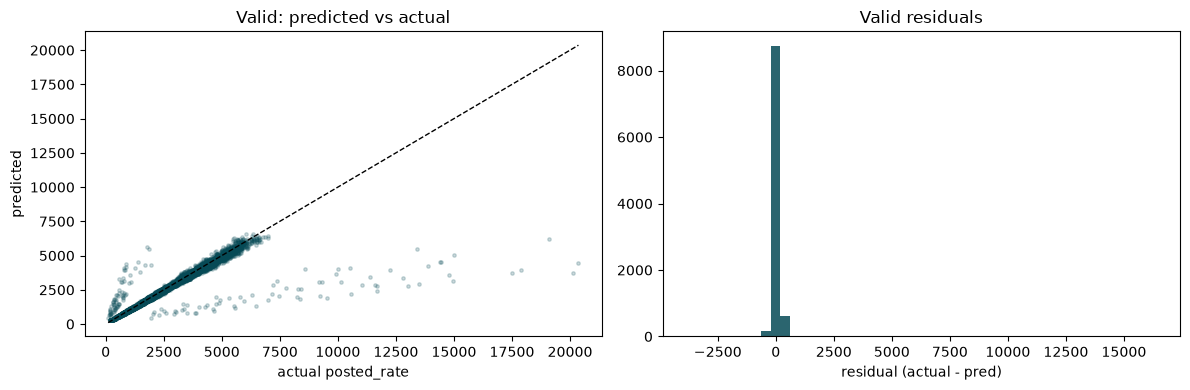

count     9670.000000
mean        61.674896
std        632.850570
min      -3860.424745
25%        -27.508781
50%         16.841660
75%         76.369914
max      16402.894456
Name: posted_rate, dtype: float64


In [90]:
# Residual quick look on valid set
resid = y_valid - pred_valid
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_valid, pred_valid, s=6, alpha=0.2, color="#064A56")
lims = [min(y_valid.min(), pred_valid.min()), max(y_valid.max(), pred_valid.max())]
axes[0].plot(lims, lims, color="black", linewidth=1, linestyle="--")
axes[0].set_xlabel("actual posted_rate")
axes[0].set_ylabel("predicted")
axes[0].set_title("Valid: predicted vs actual")

axes[1].hist(resid, bins=50, color="#064A56", alpha=0.85)
axes[1].set_xlabel("residual (actual - pred)")
axes[1].set_title("Valid residuals")
plt.tight_layout()
plt.show()

print(resid.describe())


#### Final predictions + scorer

1. Refit the **selected** model on all labeled `train-test` data (same feature pipeline).
2. Predict blind `data/validation.csv` -> `validation_predictions.csv`.
3. Fill December chart inputs (add `market_index` / `quote_signal` for the model, then write `predicted_rate`).
4. Run `score.py` to validate files and write `scorer_results/candidate_december.png`.

Requires earlier cells: `df_eda`, FE helpers, `feature_cols`, `model`, `best_name`.


In [ ]:
# Refit selected model on all available training data
full_df = df_eda.copy()  # already has datetime date (+ rate_per_mile from EDA)
assert "posted_rate" in full_df.columns

final_impute_stats = fit_impute_stats(full_df)
full_fe = add_date_features(
    add_equipment_ohe(apply_impute(full_df, final_impute_stats), final_impute_stats["equipment_categories"])
)
full_fe = run_feature_pipeline(full_fe)

missing_feats = [c for c in feature_cols if c not in full_fe.columns]
assert not missing_feats, f"Missing features after FE: {missing_feats}"

X_full = full_fe[feature_cols]
y_full = full_fe["posted_rate"]

final_model = clone(model)  # same class/hyperparams as selected valid winner
final_model.fit(X_full, y_full)
print(f"Refit selected model on full labeled data: {best_name}")
print(f"X_full shape: {X_full.shape}")


Refit selected model on full labeled data: HistGradientBoosting
X_full shape: (48000, 22)


In [ ]:
# Run on provided validation set
blind_raw = pd.read_csv("data/validation.csv")
blind_raw["date"] = pd.to_datetime(blind_raw["date"])

blind_fe = add_date_features(
    add_equipment_ohe(apply_impute(blind_raw, final_impute_stats), final_impute_stats["equipment_categories"])
)
blind_fe = run_feature_pipeline(blind_fe)

assert not blind_fe[feature_cols].isna().any().any(), blind_fe[feature_cols].isna().sum()[blind_fe[feature_cols].isna().any()]

blind_pred = final_model.predict(blind_fe[feature_cols])
blind_pred = np.maximum(blind_pred, 0.01)  # scorer requires positive rates

validation_predictions = pd.DataFrame(
    {
        "load_id": blind_raw["load_id"].astype(str).values,
        "predicted_rate": blind_pred,
    }
)
pred_path = Path("validation_predictions.csv")
validation_predictions.to_csv(pred_path, index=False)
print(f"Wrote {pred_path.resolve()} | rows={len(validation_predictions):,}")
print(validation_predictions.head())
print("predicted_rate describe:\n", validation_predictions["predicted_rate"].describe())


Wrote E:\Job hunt 2026\Spotter\SpotterAssessment\validation_predictions.csv | rows=12,000
     load_id  predicted_rate
0  TE-000001      836.308926
1  TE-000002     4845.516504
2  TE-000003     5561.946947
3  TE-000004     4226.764810
4  TE-000005     1785.092175
predicted_rate describe:
 count    12000.000000
mean      2387.973366
std       1373.255662
min        251.342844
25%       1282.118835
50%       2079.527366
75%       3402.293817
max       6911.091047
Name: predicted_rate, dtype: float64


In [94]:
# --- 3) December fixed-lane chart inputs ---
# Template has no market_index / quote_signal; fill from full labeled train stats.
dec_path = Path("data/december-chart-inputs.csv")
december = pd.read_csv(dec_path)
december["date"] = pd.to_datetime(december["date"])

# Keep a clean template copy of the original columns before modeling extras
december_template_cols = ["pickup", "delivery", "distance", "equipment", "weight", "date", "predicted_rate"]

last_month = full_df["date"].dt.to_period("M").max()
mi_fill = final_impute_stats["market_index_by_month"].get(
    last_month, final_impute_stats["market_index_global"]
)
qs_fill = full_df.loc[full_df["equipment"].eq("Dry Van"), "quote_signal"].median()
if pd.isna(qs_fill):
    qs_fill = full_df["quote_signal"].median()

december_model = december.copy()
december_model["market_index"] = float(mi_fill)
december_model["quote_signal"] = float(qs_fill)

# Coords only needed if present in feature_cols; add stable city lookups anyway
city_coords = (
    pd.concat(
        [
            full_df[["pickup", "pickup_lat", "pickup_lon"]].rename(
                columns={"pickup": "city", "pickup_lat": "lat", "pickup_lon": "lon"}
            ),
            full_df[["delivery", "delivery_lat", "delivery_lon"]].rename(
                columns={"delivery": "city", "delivery_lat": "lat", "delivery_lon": "lon"}
            ),
        ],
        ignore_index=True,
    )
    .groupby("city", as_index=True)
    .median(numeric_only=True)
)

def _city_coord(city: str, which: str, fallback: float) -> float:
    if city in city_coords.index:
        return float(city_coords.loc[city, which])
    return float(fallback)

december_model["pickup_lat"] = _city_coord("Lexington", "lat", full_df["pickup_lat"].median())
december_model["pickup_lon"] = _city_coord("Lexington", "lon", full_df["pickup_lon"].median())
december_model["delivery_lat"] = _city_coord("Fort Wayne", "lat", full_df["delivery_lat"].median())
december_model["delivery_lon"] = _city_coord("Fort Wayne", "lon", full_df["delivery_lon"].median())

dec_fe = add_date_features(
    add_equipment_ohe(apply_impute(december_model, final_impute_stats), final_impute_stats["equipment_categories"])
)
dec_fe = run_feature_pipeline(dec_fe)

assert not dec_fe[feature_cols].isna().any().any(), dec_fe[feature_cols].isna().sum()[dec_fe[feature_cols].isna().any()]

dec_pred = np.maximum(final_model.predict(dec_fe[feature_cols]), 0.01)

december_out = december[december_template_cols].copy()
december_out["predicted_rate"] = dec_pred
december_out["date"] = pd.to_datetime(december_out["date"]).dt.strftime("%Y-%m-%d")
december_out.to_csv(dec_path, index=False)

print(f"Updated {dec_path.resolve()}")
print(f"market_index fill={float(mi_fill):.5f} (from {last_month}), quote_signal fill={float(qs_fill):.5f}")
print(december_out.head())
print("December predicted_rate describe:\n", december_out["predicted_rate"].describe())


Updated E:\Job hunt 2026\Spotter\SpotterAssessment\data\december-chart-inputs.csv
market_index fill=0.95818 (from 2025-10), quote_signal fill=2.04657
      pickup    delivery  distance equipment  weight        date  \
0  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-01   
1  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-02   
2  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-03   
3  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-04   
4  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-05   

   predicted_rate  
0      856.575475  
1      858.453972  
2      860.514071  
3      859.415958  
4      857.537461  
December predicted_rate describe:
 count     31.000000
mean     858.128484
std        1.415582
min      856.575475
25%      856.575475
50%      857.537461
75%      859.415958
max      860.514071
Name: predicted_rate, dtype: float64


In [ ]:
# Run scorer and generate december chart
cmd = [
    sys.executable,
    "score.py",
    "--predictions",
    "validation_predictions.csv",
    "--december-predictions",
    "data/december-chart-inputs.csv",
    "--output-dir",
    "scorer_results",
]
print("Running:", " ".join(cmd))
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError(f"score.py failed with exit code {result.returncode}")

chart_path = Path("scorer_results/candidate_december.png")
print("Chart exists:", chart_path.exists(), "->", chart_path.resolve())


Running: e:\Programs\anaconda3\envs\spotter\python.exe score.py --predictions validation_predictions.csv --december-predictions data/december-chart-inputs.csv --output-dir scorer_results
Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results\candidate_december.png
Final validation metrics are calculated by Spotter after submission.

Chart exists: True -> E:\Job hunt 2026\Spotter\SpotterAssessment\scorer_results\candidate_december.png
